Ok, so I need to make an HR diagram. I should manually subdivide the target_table by spectral type inside this notebook instead of creating a bunch of separate files externally, or making the script itself do the separate plotting.

I'm repurposing this to do the plotting for the H-R diagram for the Kdwarf impostors paper/presentation.

In [1]:

from __future__ import print_function


#import matplotlib
#matplotlib.use('pdf')



import numpy as np
#from astroquery.gaia import Gaia
import astropy.units as u
import os
import sys
import astropy.coordinates as coord
from astropy.table import Table, QTable
import matplotlib.pyplot as plt
import scipy.stats as scistats
#import seaborn as sns
#import astropy

sys.path.append('../')
sys.path.append('/Users/BenKaiser/Desktop/radial_velocity_calculations/')
import spec_plot_tools as spt

import time
start = time.time()


I do need to figure out how to get the Gaia scripts into my import path though because I'm not currently over there.... Maybe I should just move this over into the Gaia directory, externally? That's probably the easiest solution to this problem. I'm going to just move this jupyter notebook.

Ok, I have moved this into the Gaia directory and restarted the kernel. Now let's see if this import works...

In [2]:

#import passband_model_convolution as pmc
import gaia_extinction
#import wdatmos
import plotting_dicts as pod

And import the actual script that does the plotting

In [3]:
import plot_alt_cmdDR3 as pac

Also need to import the panstarrs plotting code for later use

So, it did execute all of that crap like I expected, and it most likely assigned a bunch of variables that I'll now need to be careful of... actually those should have been assigned inside the script I imported, so it should be pac.variable, so I should be safe to do stuff

So the problem is the import never stops running. I added in the "if" statement that makes the plotting stuff only execute if the script is the main file called, so that should fix it. Now I'll restart the damn kernel again...

In [4]:
target_dir='/Users/BenKaiser/Desktop/Kdwarf_impostor_paper'
os.chdir(target_dir)
figure_output_dir='/Users/BenKaiser/Desktop/Kdwarf_impostor_paper/figures/'



In [5]:
J0212_file='WDJ0212m5522_coolDZ_gaiaDR3.csv'
impostors_file='bestchance_potential_WDs_mistaken_for_Kstars.csv'


In [6]:
J0212_table=Table.read(J0212_file)
impostors_table=Table.read(impostors_file)



Ok, I need to make this generate a nice litte BP-RP H-R diagram with Nicola's cuts drawn onto it.

(20504,)
g_calc-g_measured 0.000997658464953588 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.000997658464953588 
rp_calc - rp_measured 0.014024958935660692 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -4.2895883004707045
0.7104116995292955 15.23661637027016
WD J0212-5522
g_calc-g_measured 0.000998906933110888 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.000998906933110888 
rp_calc - rp_measured 0.01402442370614665 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -3.898981516773036
1.101018483226964 10.569729723656248
J0212-5522 A
/Users/BenKaiser/Desktop/Kdwarf_impostor_paper
/Users/BenKaiser/Desktop/Kdwarf_impostor_paper/figures
1768543560.9097788


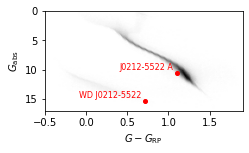

In [7]:
#plt.rc('font',family='Microsoft Sans Serif',size=12)
#fig= plt.figure(figsize=(10,5))
#plt.figure(figsize=(7.25,9.67), constrained_layout=False)
#plt.figure(figsize=(9.5,9.67), constrained_layout=True)
#plt.figure(figsize=(6.5,9.67/9.5*6.5), constrained_layout=False)
fig=spt.start_ApJ_fig(width_cols=1,width_height=[1.,6./10.])


colours=['g','rp']
j0212_size=4

pac.plot_bkg_cmd(colours=colours)
#pac.plot_target_table(impostors_table, colours=colours, list_color='#1ca1f2')
pac.plot_target_table(J0212_table, colours=colours, list_color= 'red',markersize=j0212_size)

#plt.errorbar(np.nan,np.nan,color='#1ca1f2', linestyle='None',label='K impostor cand.',marker='o')
plt.errorbar(np.nan,np.nan,color='red', linestyle='None',label='WD J0212–5522 and A',markersize=j0212_size,marker='o')


plt.ylabel(r'$G_{\mathrm{abs}}$')
plt.xlabel(r'$G - G_{\mathrm{RP}}$')
#plt.ylim(17,-2.5)
plt.ylim(17,0)
plt.xlim(-0.5,1.9)
#plt.subplots_adjust(wspace = 0, hspace = 0, top = 0.90, bottom = 0.10, left = 0.12, right = 0.90)


#plt.legend()
print(os.getcwd())
os.chdir(figure_output_dir)
print(os.getcwd())
start = time.time()
print(start)
time_string=str(start).split('.')[0]
#plt.savefig(figure_output_dir+"J0212_HR_diagram_"+time_string+'.pdf')#plt.grid(True)
#plt.savefig(figure_output_dir+"cand_HR_diagram_"+time_string+'.pdf')#plt.grid(True)


plt.show()


#plt.show()

## HR diagram with only the main-sequence companion, so zoomed

(20504,)
g_calc-g_measured 0.000997658464953588 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.000997658464953588 
rp_calc - rp_measured 0.014024958935660692 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -4.2895883004707045
0.7104116995292955 15.23661637027016
WD J0212-5522
g_calc-g_measured 0.000998906933110888 
index_length 10000
mag_dist.shape (10000,)
g_calc-bp_measured 0.000998906933110888 
rp_calc - rp_measured 0.01402442370614665 
type(target_colour_dif) <class 'numpy.float64'>
target_colour_dif value comparison True False False
target_colour_dif-5 -3.898981516773036
1.101018483226964 10.569729723656248
J0212-5522 A
/Users/BenKaiser/Desktop/Kdwarf_impostor_paper/figures
/Users/BenKaiser/Desktop/Kdwarf_impostor_paper/figures
1768543593.616008


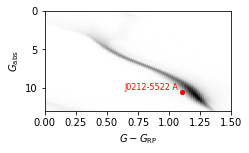

In [10]:
#plt.rc('font',family='Microsoft Sans Serif',size=12)
#fig= plt.figure(figsize=(10,5))
#plt.figure(figsize=(7.25,9.67), constrained_layout=False)
#plt.figure(figsize=(9.5,9.67), constrained_layout=True)
#plt.figure(figsize=(6.5,9.67/9.5*6.5), constrained_layout=False)
fig=spt.start_ApJ_fig(width_cols=1,width_height=[1.,6./10.])


colours=['g','rp']
j0212_size=4

pac.plot_bkg_cmd(colours=colours)
#pac.plot_target_table(impostors_table, colours=colours, list_color='#1ca1f2')
pac.plot_target_table(J0212_table, colours=colours, list_color= 'red',markersize=j0212_size)

#plt.errorbar(np.nan,np.nan,color='#1ca1f2', linestyle='None',label='K impostor cand.',marker='o')
plt.errorbar(np.nan,np.nan,color='red', linestyle='None',label='WD J0212–5522 and A',markersize=j0212_size,marker='o')


plt.ylabel(r'$G_{\mathrm{abs}}$')
plt.xlabel(r'$G - G_{\mathrm{RP}}$')
#plt.ylim(17,-2.5)
plt.ylim(13,0)
plt.xlim(-0,1.5)
#plt.subplots_adjust(wspace = 0, hspace = 0, top = 0.90, bottom = 0.10, left = 0.12, right = 0.90)


#plt.legend()
print(os.getcwd())
os.chdir(figure_output_dir)
print(os.getcwd())
start = time.time()
print(start)
time_string=str(start).split('.')[0]
#plt.savefig(figure_output_dir+"J0212_HR_diagram_"+time_string+'.pdf')#plt.grid(True)
#plt.savefig(figure_output_dir+"cand_HR_diagram_"+time_string+'.pdf')#plt.grid(True)
plt.savefig(figure_output_dir+"J0212A_HR_diagram_"+time_string+'.pdf')#plt.grid(True)


plt.show()


#plt.show()

Ay oh! It worked! Now onto the division by group. I need to check what the column name is... And I'll probably need to reimpose it onto the CSV again...

In [9]:
plt.show()